<a href="https://colab.research.google.com/github/zelal-Eizaldeen/deeplearning_course/blob/main/UsingPretrainedGloVeEmbeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- In this programming example, we will show how to **use pre-trained embeddings**. We're going to use **embeddings known as GloVe**. Before diving into the programming example, let's just discuss a little bit about similarity metrics for word vectors.

# similarity metrics for word vectors.

In the figure, we see **three word vectors**, A, B, and C. We see that these **are not normalized in that they have different lengths**.

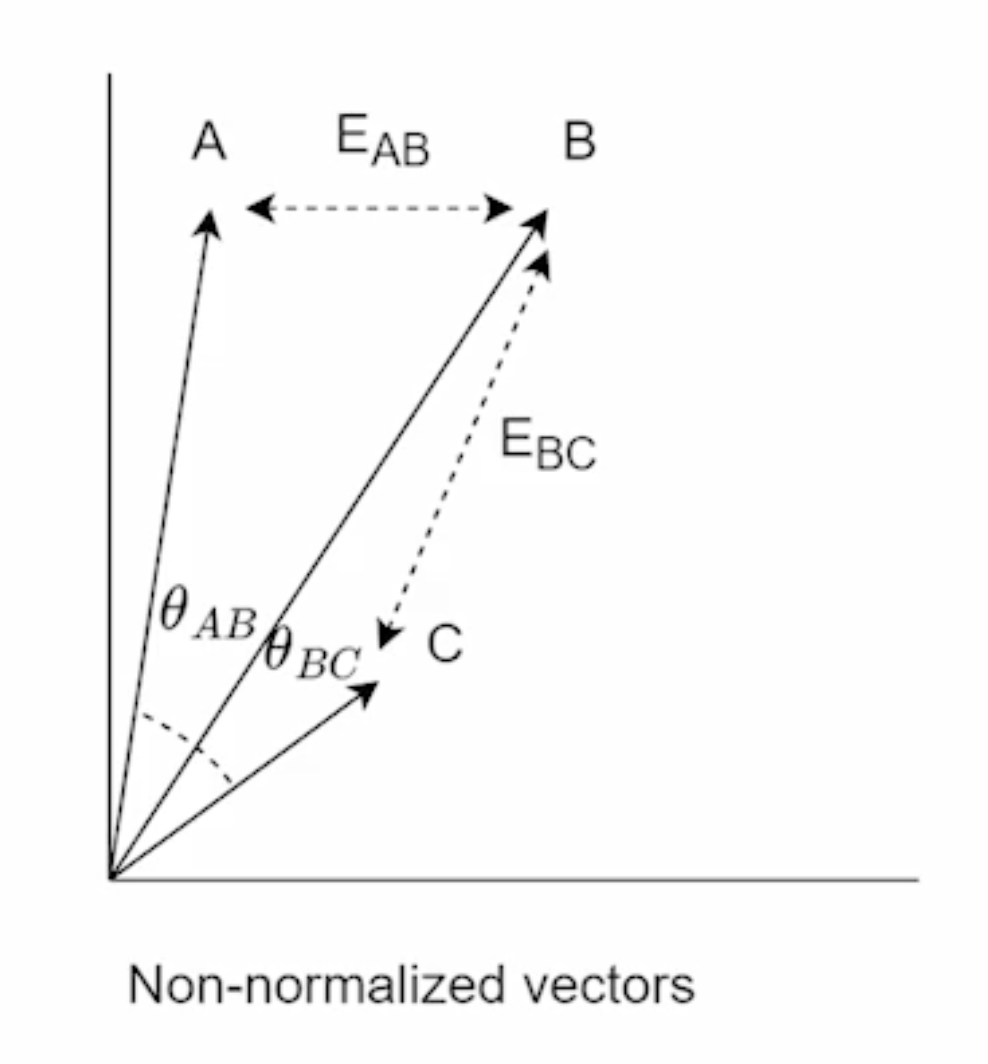

We see that the distance between A and B is less than the distance between B and C in this case.

One very intuitive metric when looking at the distance between vectors is to use t***he Euclidean distance.***

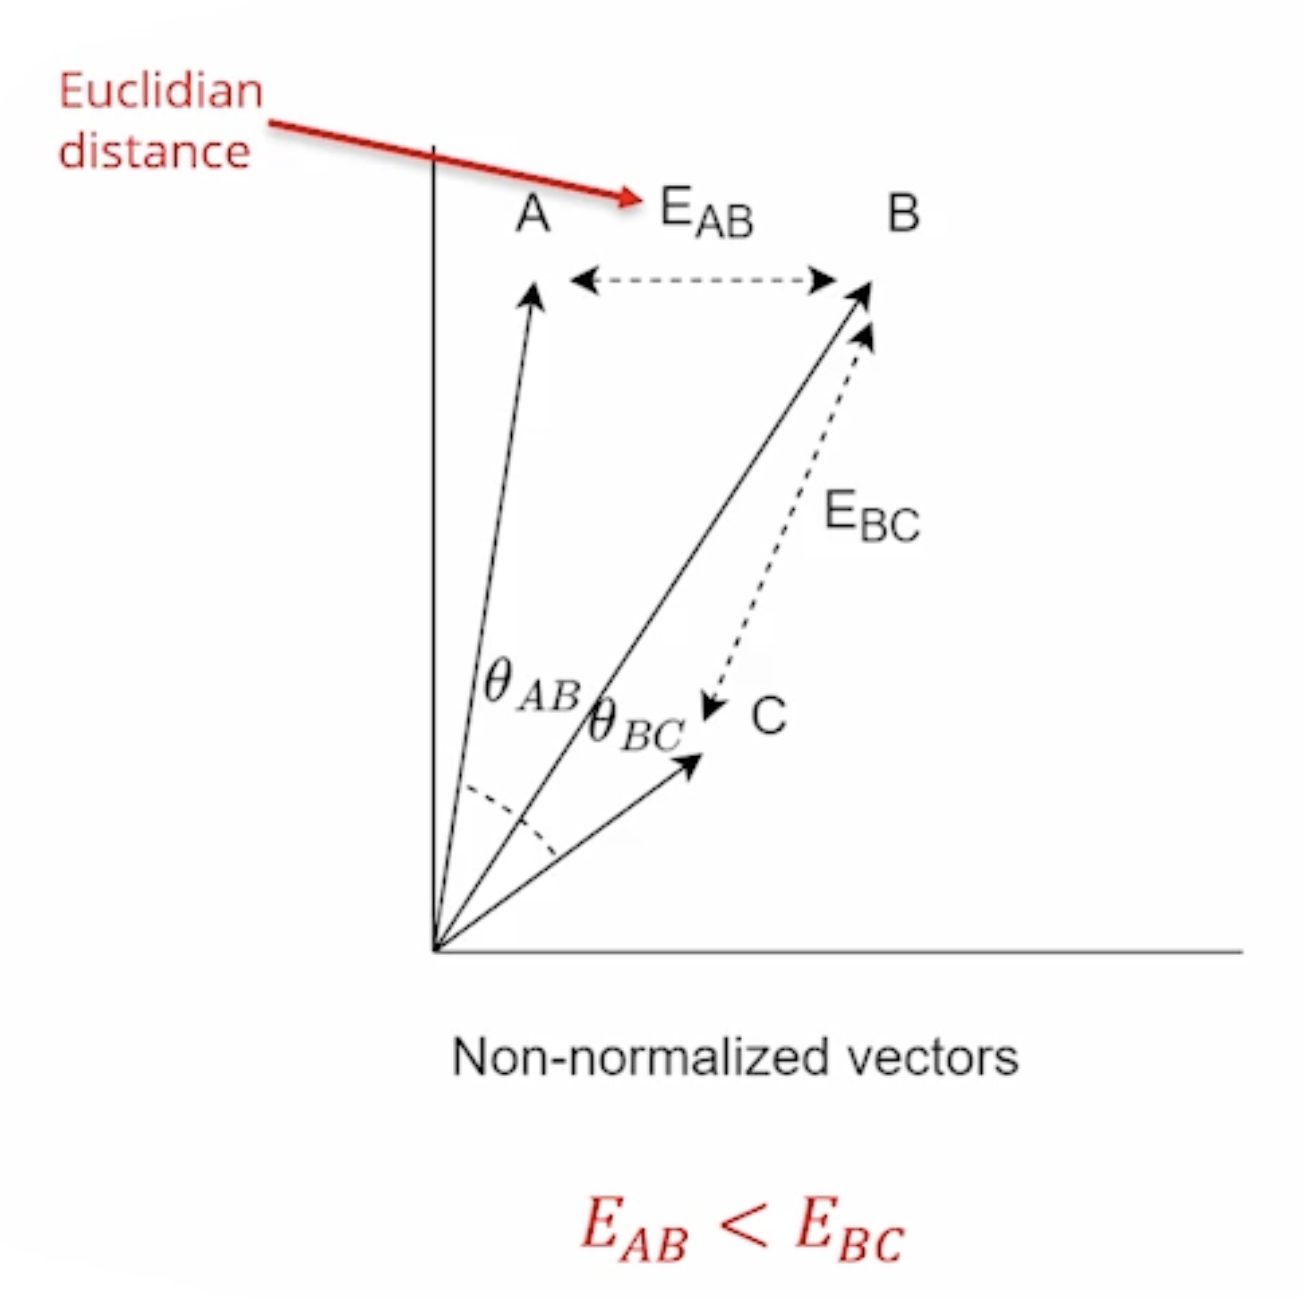

 However, **there are also other distance metrics**. We can use the **cosine distance**, for example. **It looks at the angle between the vectors, and we can see that the angle between A and B is greater than the angle between B and C**.

**So according to cosine distance**, B is closer to C than A is to B. That **raises the question what metric to use, and there is no clear answer**. Sometimes Euclidean distance works better, sometimes cosine distance work better.

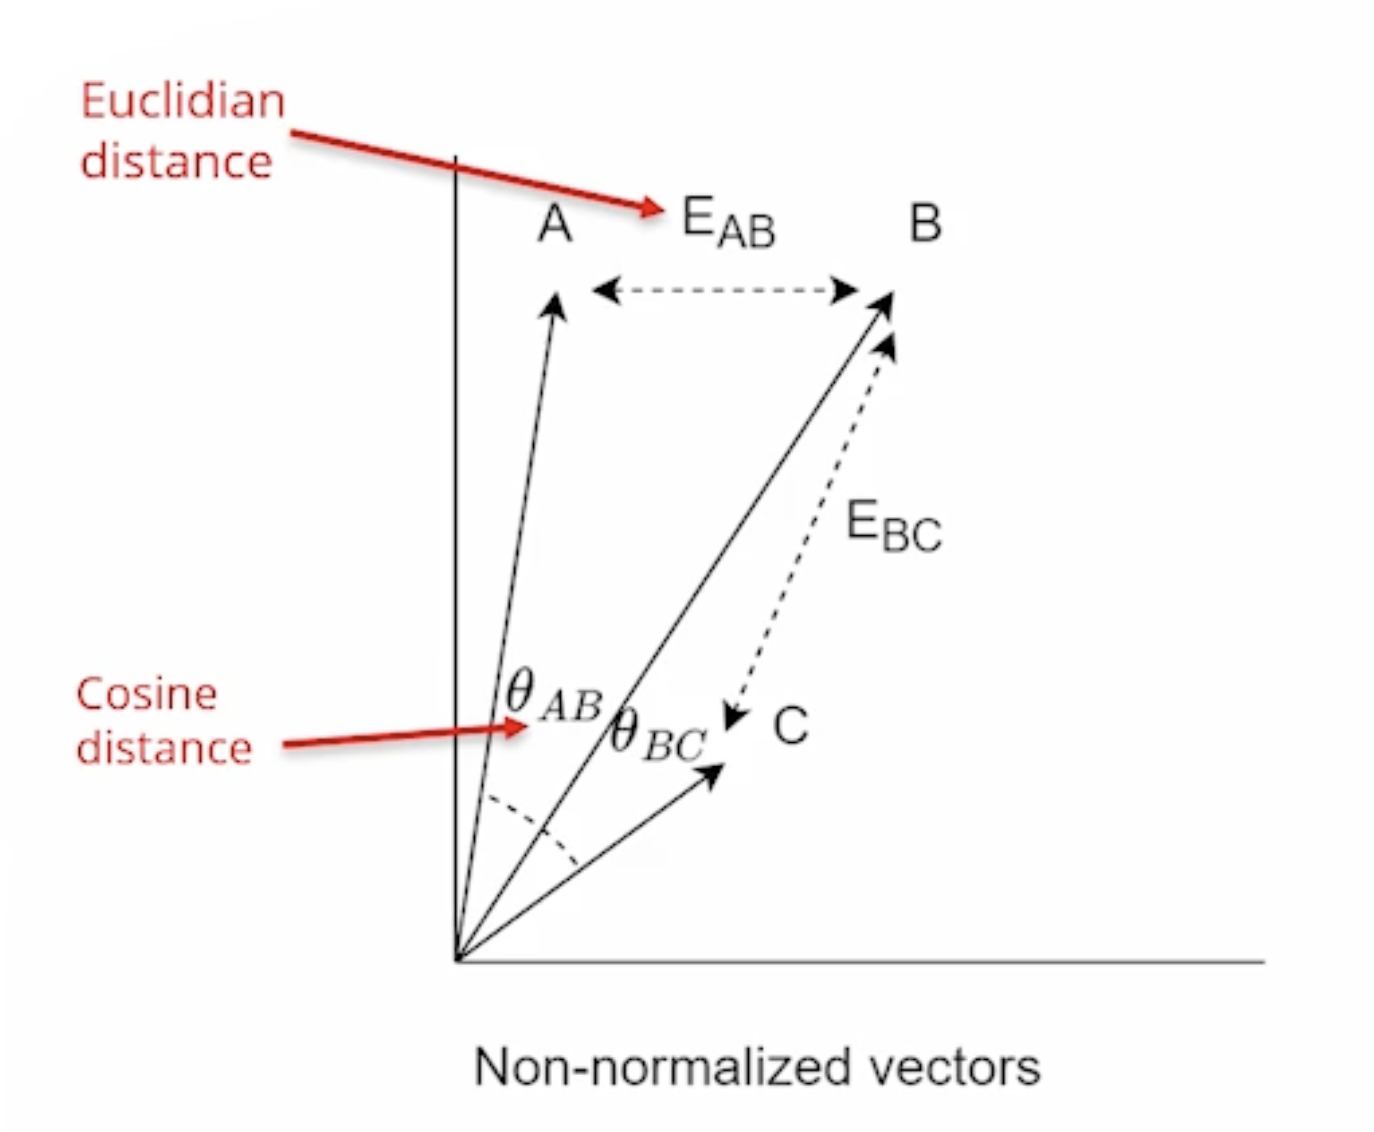

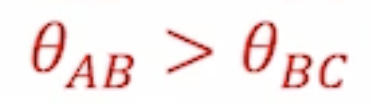

However, it's also worth noting that if **we work with normalized vectors**, **both metrics will yield the same**. That is, we see that both for Euclidean distance and cosine distance, B and C are closer to each other when we are working with normalized vectors.

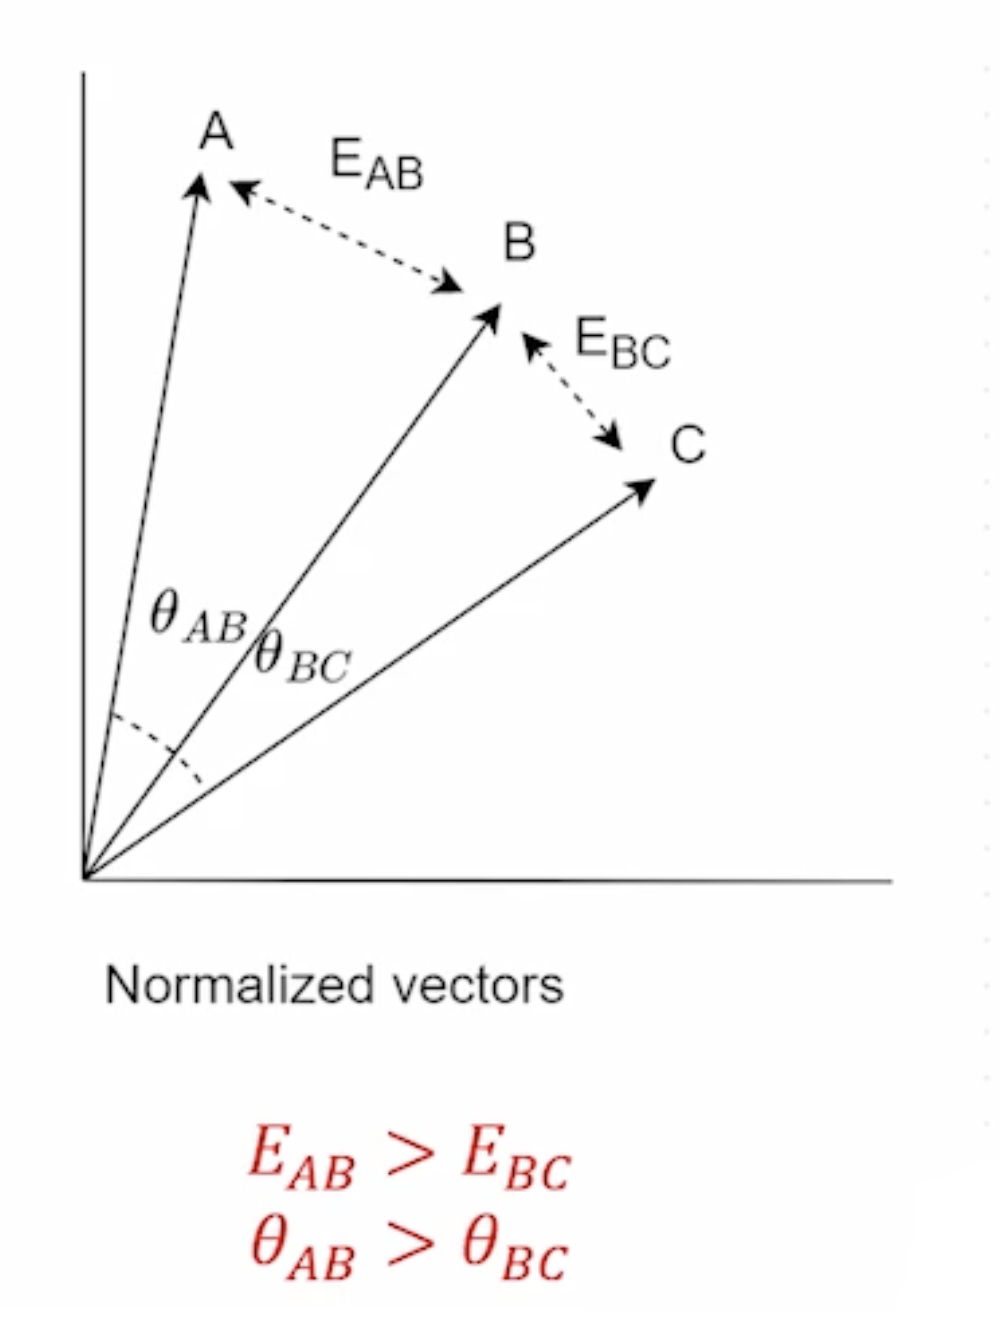

In this Google Colab notebook, we will now look at how we can read some **pre-trained GloVe embeddings** and see how we can use them and do some word vector arithmetic on them. So what we will do here is simply read these embeddings from a file. So the file for each line there will contain the word and then the corresponding numbers for that embedding.

So we will read for **each line, we will split the line into getting the word itself**, which is **the first entry on that line**. And **then we will create an array containing all the numbers corresponding to that**.

So then we have ***embeddings*** **dictionary**, which have the embedding so we can index that by a word. And from that we will get the corresponding vector. So we have defined that function here that will read the file.


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import scipy.spatial

# Read embeddings from file.
def read_embeddings():
    FILE_NAME = '../data/glove.6B.100d.txt'
    embeddings = {}
    file = open(FILE_NAME, 'r', encoding='utf-8')
    for line in file:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:],
                            dtype='float32')
        embeddings[word] = vector
    file.close()
    print('Read %s embeddings.' % len(embeddings))
    return embeddings

 We also need a function that can **find the closest match**.
 **We want to look at what embeddings are close to other embeddings**. So this method will take the full dictionary of embeddings and a specific vector and a number N. And then it'll go through all of the embeddings, calculate the distance between those embeddings, and this input vector. And then it'll print the ones, **the N closest vectors and as the distance metric, this time we will use the cosine distance**. So this **function will simply print out the N closest embeddings**.

In [3]:
def print_n_closest(embeddings, vec0, n):
    word_distances = {}
    for (word, vec1) in embeddings.items():
        distance = scipy.spatial.distance.cosine(
            vec1, vec0)
        word_distances[distance] = word
    # Print words sorted by distance.
    for distance in sorted(word_distances.keys())[:n]:
        word = word_distances[distance]
        print(word + ': %6.3f' % distance)

we're gonna first read the embeddings so that we'll call the function that we had further up. And then we will look up the embedding for hello. And we will print the N closest words to that. And then we'll do the same thing with precisely. And the same thing with dog.

In [4]:
embeddings = read_embeddings()

lookup_word = 'hello'
print('\nWords closest to ' + lookup_word)
print_n_closest(embeddings,
                embeddings[lookup_word], 3)

lookup_word = 'precisely'
print('\nWords closest to ' + lookup_word)
print_n_closest(embeddings,
                embeddings[lookup_word], 3)

lookup_word = 'dog'
print('\nWords closest to ' + lookup_word)
print_n_closest(embeddings,
                embeddings[lookup_word], 3)

Read 400000 embeddings.

Words closest to hello
hello:  0.000
goodbye:  0.209
hey:  0.283

Words closest to precisely
precisely:  0.000
exactly:  0.147
accurately:  0.293

Words closest to dog
dog:  0.000
cat:  0.120
dogs:  0.166


We see we have 400,000 embeddings that we have in the file. So we read all of those and then the words that are closest to hello is hello itself and then we have goodbye and hey, and **this is the distance**.

We see that a word that is very close to precisely is exactly, another one is accurately.

So these embeddings clearly **have grouped words so that similar words are close together**. Similar for dog, we have cat and dogs. Those are two words that are very close to dog. So that's just to show a little bit how **these embeddings are distributed** **across the vector space**.

But let's now look at if we try to do **word vector arithmetic** as well. So we are going to take the **word king first and print the N closest embeddings to that**. **And then we are going to take the vector for king. We subtract man and add woman, and then take that resulting embedding and see which words that are closest to that**.

We see that the words that are **closest to king are prince and queen,**  So those are related to king.

**And now see when we subtract the male component from king** **and add woman, that queen is closer to king than monarch**. **So this actually, this cannot show that we are now getting closer to queen than we were to prince.** And that's how we can use **word vector arithmetic to see these kind of relationships between words. **

In [5]:
lookup_word = 'king'
print('\nWords closest to ' + lookup_word)
print_n_closest(embeddings,
                embeddings[lookup_word], 3)

lookup_word = '(king - man + woman)'
print('\nWords closest to ' + lookup_word)
vec = embeddings['king'] - embeddings[
    'man'] + embeddings['woman']
print_n_closest(embeddings, vec, 3)


Words closest to king
king:  0.000
prince:  0.232
queen:  0.249

Words closest to (king - man + woman)
king:  0.145
queen:  0.217
monarch:  0.307


**We will work with cities and countries instead**. So we have the **country Kuwait** and **see what the words are closest to that**. And we will take the **city of Doha**, which is the capital of Qatar. I **subtract  Qatar from Doha and add the Kuwait component**

We can see that the words that are closest to the **word Kuwait are the neighboring countries of Bahrain and Qatar**.

 And the words **that are closest to the city of Doha are Qatar and Qatari**

 And then now it's looking **at the word vector arithmetic.** When we remove Qatar from Doha and add Kuwait, we end up with Iraq**, **which is close to Kuwait**.



In [10]:
lookup_word = 'kuwait'
print('\nWords closest to ' + lookup_word)
print_n_closest(embeddings,
                embeddings[lookup_word], 3)

lookup_word = 'doha'
print('\nWords closest to ' + lookup_word)
print_n_closest(embeddings,
                embeddings[lookup_word], 3)

lookup_word = '(doha - qatar + kuwait)'
print('\nWords closest to ' + lookup_word)
vec = embeddings['doha'] - embeddings[
    'qatar'] + embeddings['kuwait']
print_n_closest(embeddings, vec, 3)


Words closest to kuwait
kuwait:  0.000
bahrain:  0.157
qatar:  0.165

Words closest to doha
doha:  0.000
qatar:  0.343
qatari:  0.363

Words closest to (doha - qatar + kuwait)
doha:  0.160
kuwait:  0.334
iraq:  0.407
